In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('default')
from common.normalized_env_66k import CoppeliaSimEnv
# from common.normalized_env_66k_legloss import CoppeliaSimEnv
import os

# ======== Parameters (modify these as needed) ========= #
ENV_ID = "Medauroidea_66k_aug3c_uneven_flat"
ALGO = "airl_logit_vx"
FILENAME = "20251018-2026" 
STEP_NUM = "190000"  
EPISODE = 5 # 
start = 250 # 
end = 300 #2
fig_length = 4
fig_width = 2

STATES_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_states.csv"
ACTIONS_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_actions.csv"
VEL_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_velocities.csv"
FOOT_TRAJ_PATH = f"logs/{ENV_ID}/{ALGO}/{FILENAME}/eval/step{STEP_NUM}/episode_{EPISODE}_foot_trajs.csv"

os.makedirs(f"evaluation/{ENV_ID}/{ALGO}/{FILENAME}/step{STEP_NUM}/episode_{EPISODE}/", exist_ok=True)
SAVE_PATH = f"evaluation/{ENV_ID}/{ALGO}/{FILENAME}/step{STEP_NUM}/episode_{EPISODE}"

# ======== Read Data ======== #
states = pd.read_csv(STATES_PATH, header=None, index_col=None)
actions = pd.read_csv(ACTIONS_PATH, header=None, index_col=None)
actions.columns = ['LF_ThC', 'LF_CTr', 'LF_FTi', 'LM_ThC', 'LM_CTr', 'LM_FTi', 'LH_ThC', 'LH_CTr', 'LH_FTi',
                                     'RF_ThC', 'RF_CTr', 'RF_FTi', 'RM_ThC', 'RM_CTr', 'RM_FTi', 'RH_ThC', 'RH_CTr', 'RH_FTi']
                                    #  'RF_ThC', 'RF_CTr', 'RF_FTi', 'RH_ThC', 'RH_CTr', 'RH_FTi']
velocities = pd.read_csv(VEL_PATH, header=None, index_col=None)
foot_trajs = pd.read_csv(FOOT_TRAJ_PATH, header=None, index_col=None)

# ======== Denormalize Data ======== #
env = CoppeliaSimEnv(simulation = False)
states = pd.DataFrame(env.denormalize_observation(states))
actions = env.denormalize_action(actions)

states.columns = [
                #   'body_x', 'body_y',
                  'body_z', 'body_roll', 'body_pitch', 'body_yaw', 
                  'LF_ThC', 'LF_CTr', 'LF_FTi', 'LM_ThC', 'LM_CTr', 'LM_FTi', 'LH_ThC', 'LH_CTr', 'LH_FTi',
                  'RF_ThC', 'RF_CTr', 'RF_FTi', 'RM_ThC', 'RM_CTr', 'RM_FTi', 'RH_ThC', 'RH_CTr', 'RH_FTi',
                #   'RF_ThC', 'RF_CTr', 'RF_FTi', 'RH_ThC', 'RH_CTr', 'RH_FTi',
                  'force_LF', 'force_LM', 'force_LH', 'force_RF', 'force_RM', 'force_RH',
                #   'foot_traj_LF', 'foot_traj_LM', 'foot_traj_LH', 'foot_traj_RF', 'foot_traj_RM', 'foot_traj_RH',
                #   'contact_FL', 'contact_ML', 'contact_HL', 'contact_FR', 'contact_MR', 'contact_HR'
                  ]

init_pos_dirction = np.array([[-1, 1, 1],
                                                        [-1, 1, 1],
                                                        [-1, 1, 1],
                                                        [1, -1, -1],
                                                        [1, -1, -1],
                                                        [1, -1, -1]])  
for i, leg in enumerate(['LF', 'LM', 'LH', 'RF', 'RM', 'RH']):
    states[f'{leg}_ThC'] *= init_pos_dirction[i, 0]
    states[f'{leg}_CTr'] *= init_pos_dirction[i, 1]
    states[f'{leg}_FTi'] *= init_pos_dirction[i, 2]


# ======== Plotting Functions ======== #
def plot_6_legs(policy, expert, variable_name, start, end, title):
    fig, axs = plt.subplots(6, 1, figsize=(fig_length, fig_width))
    policy_data = policy[variable_name].values
    expert_data = expert[variable_name].values
    ylabel = ['LF', 'LM', 'LH', 'RF', 'RM', 'RH']
    for i in range(6):
        axs[i].plot(policy_data[start:end, i], label="policy")
        axs[i].plot(expert_data[start:end, i], label="expert")
        axs[i].set_ylabel(ylabel[i], fontsize=16)
        axs[i].tick_params(axis='both', which='major', labelsize=14)
        axs[i].grid()
    axs[0].set_title(title, fontsize=18)
    axs[-1].set_xlabel('Time (frames)', fontsize=16)
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=10, ncol=1, loc='outside center right')
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


def plot_1_joint(policy, joint_select, joint_label, start, end, title, show_mean=False, show_std=False):
    plt.figure(figsize=(fig_length, fig_width))
    if joint_select == 'front':
        leg_labels = ['LF', 'RF']
        colors = ['tab:blue', 'tab:orange']
    elif joint_select == 'middle':
        leg_labels = ['LM', 'RM']
        colors = ['tab:blue', 'tab:orange']
    elif joint_select == 'hind':
        leg_labels = ['LH', 'RH']
        colors = ['tab:blue', 'tab:orange']
    elif joint_select == 'all':
        leg_labels = ['LF', 'LM', 'LH', 'RF', 'RM', 'RH']
        colors = ['tab:blue', 'tab:green', 'tab:purple', 'tab:orange', 'tab:red', 'tab:brown']
    joint_data = []
    for leg in leg_labels:
        label = f"{leg}_{joint_label}"
        y = policy[label][start:end].values
        joint_data.append(y)
        plt.plot(policy[label][start:end], label=leg, color=colors[leg_labels.index(leg)])

            
    plt.title(title, fontsize=18)
    plt.xlabel('Time (frames)', fontsize=16)
    plt.ylabel('Angle (rad)', fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def plot_pose(policy, pose_name, start, end, title):
    plt.figure(figsize=(fig_length, fig_width))
    for pose in pose_name:
        plt.plot(policy[pose][start:end], label=f"Policy {pose}")
    plt.title(title, fontsize=18)
    plt.xlabel('Time (frames)', fontsize=16)
    plt.ylabel('Angle (rad)', fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def plot_gait(policy, foot_trajs, start, end, title):
    force_cols = ['force_LF', 'force_LM', 'force_LH', 'force_RF', 'force_RM', 'force_RH']
    foot_cols = ['foot_traj_LF', 'foot_traj_LM', 'foot_traj_LH', 'foot_traj_RF', 'foot_traj_RM', 'foot_traj_RH']
    leg_labels = ['LF', 'LM', 'LH', 'RF', 'RM', 'RH']

    def get_contact_byforce(data):
        """Compute binary contact states (1=stance, 0=swing)."""
        contact = np.zeros((len(data), len(force_cols)))
        for i, col in enumerate(force_cols):
            contact[:, i] = (data[col].abs() > 0.27).astype(int)
        return contact[start:end]

    def get_contact_byfoot(data):
        """Compute binary contact states (1=stance, 0=swing)."""
        contact = np.zeros((len(data), len(foot_cols)))
        for i, col in enumerate(foot_cols):
            contact[:, i] = (data[i].abs() < 0.02).astype(int)
        return contact[start:end]
    
    contact_policy = get_contact_byforce(policy)
    contact_foot_trajs = get_contact_byfoot(foot_trajs)

    plt.figure(figsize=(fig_length, fig_width))
    plt.imshow(contact_policy.T, aspect="auto", cmap="Greys", interpolation="nearest")
    plt.title("Policy Gait", fontsize=18)
    plt.xlabel("Time (frames)", fontsize=16)
    plt.ylabel("Legs", fontsize=16)
    plt.yticks(range(len(leg_labels)), leg_labels, fontsize=14)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(fig_length, fig_width))
    plt.imshow(contact_foot_trajs.T, aspect="auto", cmap="Greys", interpolation="nearest")
    plt.title("Policy Gait", fontsize=18)
    plt.xlabel("Time (frames)", fontsize=16)
    plt.ylabel("Legs", fontsize=16)
    plt.yticks(range(len(leg_labels)), leg_labels, fontsize=14)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.tight_layout()
    plt.show()


def plot_vel(policy, start, end, title):
    plt.figure(figsize=(fig_length, fig_width))
    plt.plot(policy[start:end])
    plt.title(title, fontsize=18)
    plt.xlabel('Time (frames)', fontsize=16)
    plt.ylabel('Vel (cm/s)', fontsize=16)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_foot_trajs(policy, start, end, title):
    fig, axs = plt.subplots(6, 1, figsize=(fig_length, fig_width*3))
    foot_labels = ['foot_traj_LF', 'foot_traj_LM', 'foot_traj_LH', 'foot_traj_RF', 'foot_traj_RM', 'foot_traj_RH']
    for i, foot in enumerate(foot_labels):
        axs[i].plot(policy[i][start:end])
        axs[i].set_ylabel(foot[-2:], fontsize=16)
        axs[i].tick_params(axis='both', which='major', labelsize=14)
        axs[i].grid()
    axs[0].set_title('Foot Trajectory (m)', fontsize=18)
    axs[-1].set_xlabel('Time (frames)', fontsize=16)
    plt.tight_layout()
    plt.show()

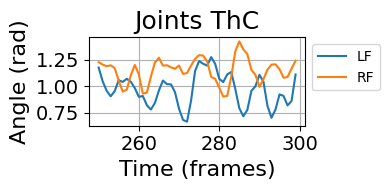

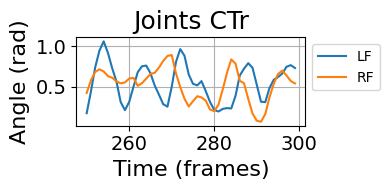

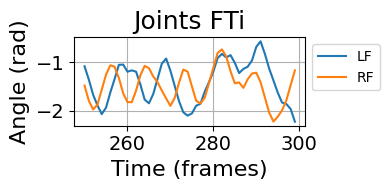

In [5]:
plot_1_joint(states, 'front', 'ThC', start, end, 'Joints ThC')
plot_1_joint(states, 'front', 'CTr', start, end, 'Joints CTr', show_mean=True, show_std=True)
plot_1_joint(states, 'front', 'FTi', start, end, 'Joints FTi')

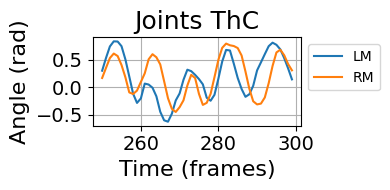

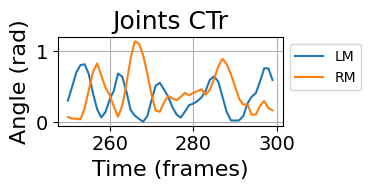

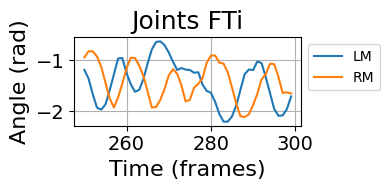

In [26]:
plot_1_joint(states, 'middle', 'ThC', start, end, 'Joints ThC')
plot_1_joint(states, 'middle', 'CTr', start, end, 'Joints CTr')
plot_1_joint(states, 'middle', 'FTi', start, end, 'Joints FTi')

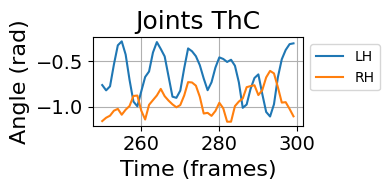

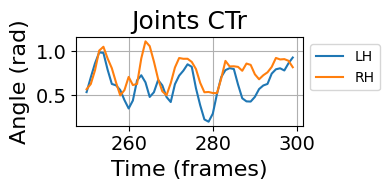

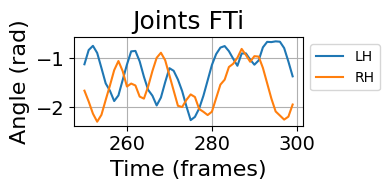

In [27]:
plot_1_joint(states, 'hind', 'ThC', start, end, 'Joints ThC')
plot_1_joint(states, 'hind', 'CTr', start, end, 'Joints CTr')
plot_1_joint(states, 'hind', 'FTi', start, end, 'Joints FTi')

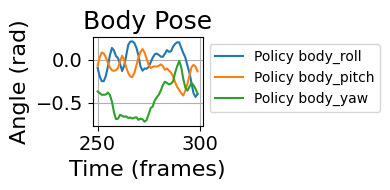

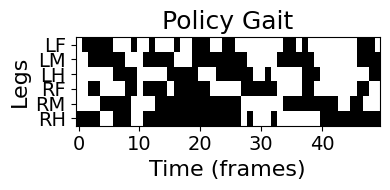

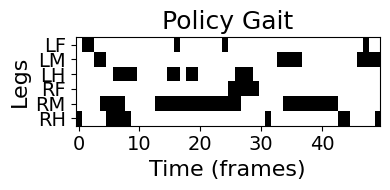

In [28]:
plot_pose(states, ['body_roll', 'body_pitch', 'body_yaw'], start, end, 'Body Pose')
plot_gait(states, foot_trajs, start, end, title="Gait Pattern")

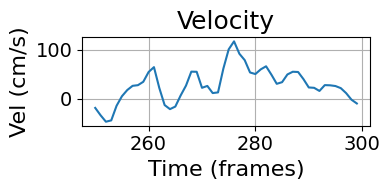

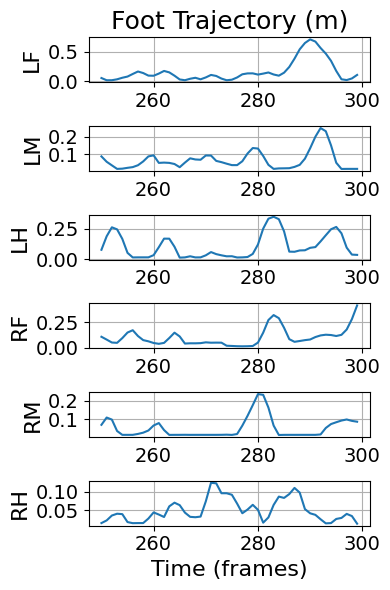

In [29]:
plot_vel(velocities, start, end, title="Velocity")
plot_foot_trajs(foot_trajs, start, end, title="Foot Trajectories")

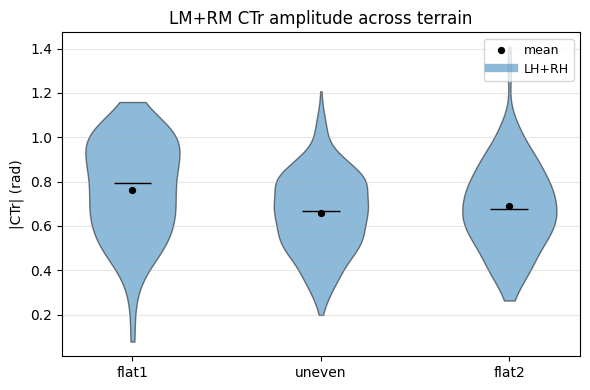

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ctr_violin(states, legs=("LM","RM"), segments=None, 
                    joint="CTr", use_abs=True, show_means=True,
                    fig_size=(6,4), colors=("tab:blue","tab:orange"),
                    title="CTr by terrain (violin)", save_path=None,
                    combine_legs=False):
    """
    小提琴图：比较不同地形段(手动给出起止帧)的 CTr 分布。
    - combine_legs=True 时，将 legs 中所有腿在每个地形段合并为一个分布，只画一支小提琴/段
    """
    assert segments and len(segments) > 0, "请提供 segments=[(name,start,end), ...]"
    n_seg = len(segments)
    fig, ax = plt.subplots(figsize=fig_size)

    if combine_legs:
        # 每段合并所有腿的数据，画一支小提琴
        vals_by_seg = []
        for name, a, b in segments:
            merged = []
            for leg in legs:
                col = f"{leg}_{joint}"
                y = states[col].iloc[a:b].values
                if use_abs:
                    y = np.abs(y)
                merged.append(y)
            if len(merged):
                vals_by_seg.append(np.concatenate(merged))
            else:
                vals_by_seg.append(np.array([]))

        parts = ax.violinplot(vals_by_seg, positions=np.arange(n_seg), widths=0.5,
                              showmeans=False, showmedians=False, showextrema=False)
        # 统一颜色
        for pc in parts['bodies']:
            pc.set_facecolor('tab:blue')
            pc.set_edgecolor('black')
            pc.set_alpha(0.5)

        # 均值/中位数
        if show_means:
            means = [np.mean(v) if len(v) else np.nan for v in vals_by_seg]
            ax.scatter(np.arange(n_seg), means, c='k', s=18, zorder=3, label="mean")
        medians = [np.median(v) if len(v) else np.nan for v in vals_by_seg]
        ax.hlines(medians, np.arange(n_seg)-0.1, np.arange(n_seg)+0.1, colors='k', lw=1, zorder=3)

        legend_label = "+".join(legs)
        ax.plot([], [], color='tab:blue', lw=6, alpha=0.5, label=legend_label)

    else:
        # 原来：每条腿每段各画一支小提琴（并排对比）
        n_legs = len(legs)
        base_positions = np.arange(n_seg)
        width = 0.35 if n_legs == 2 else 0.6 / max(n_legs,1)
        offsets = np.linspace(-width, width, n_legs)

        for li, leg in enumerate(legs):
            col = f"{leg}_{joint}"
            vals_by_seg = []
            for name, a, b in segments:
                y = states[col].iloc[a:b].values
                if use_abs:
                    y = np.abs(y)
                vals_by_seg.append(y)

            positions = base_positions + offsets[li]
            parts = ax.violinplot(vals_by_seg, positions=positions, widths=0.25,
                                  showmeans=False, showmedians=False, showextrema=False)
            for pc in parts['bodies']:
                pc.set_facecolor(colors[li % len(colors)])
                pc.set_edgecolor('black')
                pc.set_alpha(0.5)

            if show_means:
                means = [np.mean(v) if len(v) else np.nan for v in vals_by_seg]
                ax.scatter(positions, means, c='k', s=18, zorder=3, label=f"{leg} mean" if li==0 else None)

            medians = [np.median(v) if len(v) else np.nan for v in vals_by_seg]
            ax.hlines(medians, positions-0.06, positions+0.06, colors='k', lw=1, zorder=3)

            ax.plot([], [], color=colors[li % len(colors)], lw=6, alpha=0.5, label=leg)

    ax.set_xticks(np.arange(n_seg))
    ax.set_xticklabels([name for (name,_,_) in segments])
    ylab = f"{joint} angle (rad)" if not use_abs else f"|{joint}| (rad)"
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

terrain = [("flat1", 0, 40), ("uneven", 140, 440), ("flat2", 600, 700)]

plot_ctr_violin(states, legs=("LH","RH"), segments=terrain, 
                joint="CTr", use_abs=True,
                title="LM+RM CTr amplitude across terrain",
                combine_legs=True,  # 合并
                save_path=None)
